In [1]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

In [2]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]
criterion = torch.nn.CrossEntropyLoss()
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
full_dataloader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

In [4]:
def get_gradient_vector(model, dataloader, num_batches=1):
    """Helper to extract the flattened gradient vector from a model."""
    model.zero_grad()
    device = next(model.parameters()).device
    
    # Accumulate gradients over the specified number of batches
    for i, (X, y) in enumerate(dataloader):
        if i >= num_batches: break
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        loss.backward()
        
    # Flatten all gradients into a single 1D vector
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1))
    return torch.cat(grads)

In [6]:
import torch.optim as optim

# 1. Set up the SGD optimizer
# Use a "hot" temperature to ensure you land in a wide, flat valley
learning_rate = 0.01
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

print("Phase 1: Training the model to reach the local minimum...")

# 2. Train the model using your imported function
# (If your train_model returns a trained model, use it like this)
# Assuming 200 epochs is enough for this dataset to converge
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim, 
    lr=learning_rate, 
    batch_size=64, 
    epochs=200
)

# If your train_model modifies the model in-place, just call it.
# Now 'model' (or 'trained_model') is sitting at the bottom of the flat valley!
print("Training complete. The model is now in the diffusion phase.")

Phase 1: Training the model to reach the local minimum...
Epoch [100/200] | Loss: 0.0000 | Temp (lr/B): 0.00016
Epoch [200/200] | Loss: 0.0000 | Temp (lr/B): 0.00016
Training complete. The model is now in the diffusion phase.


In [7]:
print("Calculating Full-Batch True Gradient...")
true_grad = get_gradient_vector(trained_model, full_dataloader, num_batches=1)

print("Sampling Mini-Batch Gradients...")
num_samples = 500
noise_samples = []

# We will track the noise of a single, randomly chosen parameter (e.g., index 420)
# tracking the whole 14,218-dim vector 500 times takes too much memory!
param_index_to_track = 420 

for i in range(num_samples):
    # Get the gradient for just ONE mini-batch
    mini_grad = get_gradient_vector(trained_model, dataloader, num_batches=1)
    
    # V_k = (Mini-batch Grad) - (True Grad)
    # Note: In the thesis you defined V_k as True - Mini. Either way works, it's centered at 0!
    noise_vector = mini_grad - true_grad 
    
    # Store the noise for our specific parameter
    noise_samples.append(noise_vector[param_index_to_track].item())

noise_samples = np.array(noise_samples)
print("Noise sampling complete!")

Calculating Full-Batch True Gradient...
Sampling Mini-Batch Gradients...
Noise sampling complete!


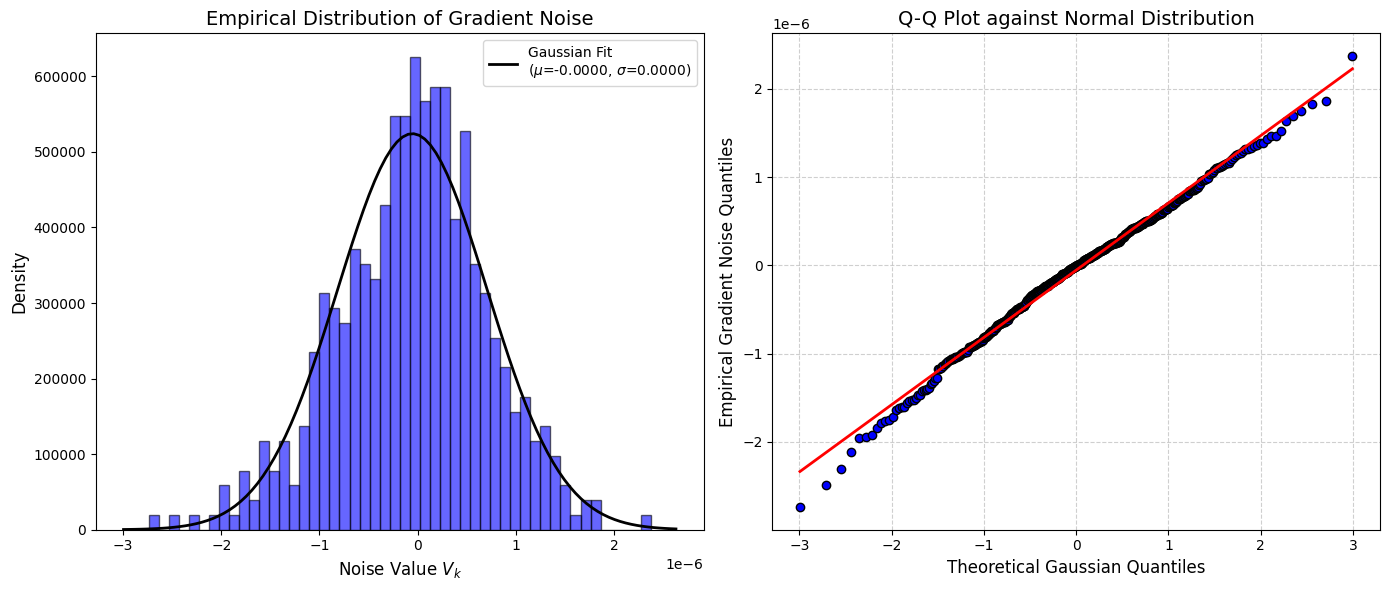

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: The Histogram with a Gaussian Fit
counts, bins, _ = ax1.hist(noise_samples, bins=50, density=True, alpha=0.6, color='blue', edgecolor='black')
mu, std = stats.norm.fit(noise_samples)
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
ax1.plot(x, p, 'k', linewidth=2, label=f'Gaussian Fit\n($\mu$={mu:.4f}, $\sigma$={std:.4f})')

ax1.set_title("Empirical Distribution of Gradient Noise", fontsize=14)
ax1.set_xlabel("Noise Value $V_k$", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.legend()

# Plot 2: The Q-Q Plot (The definitive proof)
stats.probplot(noise_samples, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('blue')
ax2.get_lines()[0].set_markeredgecolor('black')
ax2.get_lines()[1].set_color('red') # The theoretical Gaussian line
ax2.get_lines()[1].set_linewidth(2)

ax2.set_title("Q-Q Plot against Normal Distribution", fontsize=14)
ax2.set_xlabel("Theoretical Gaussian Quantiles", fontsize=12)
ax2.set_ylabel("Empirical Gradient Noise Quantiles", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("Gradient_Noise_Gaussianity_Test.png", dpi=300)
plt.show()

Sampling Mini-Batch Gradients for ALL weights...
Normalizing variances across all dimensions...
Plotting the Universal Q-Q Plot...


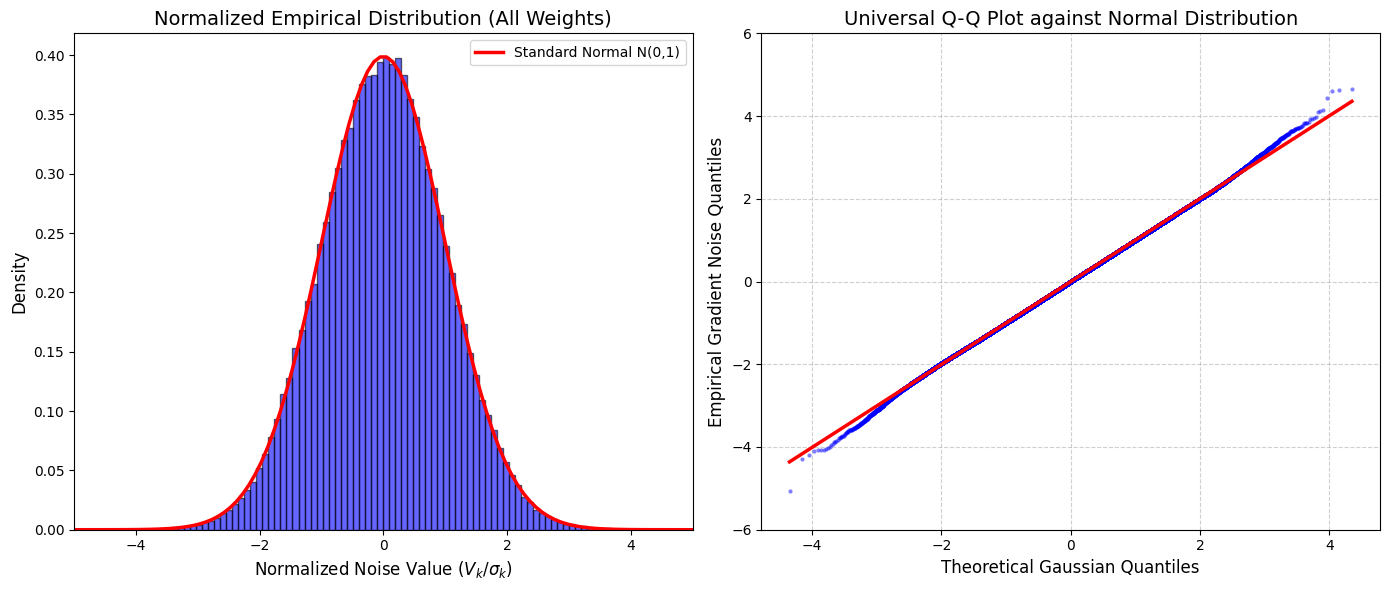

In [9]:
import torch
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# ... (Assume true_grad and dataloaders are defined as before) ...

print("Sampling Mini-Batch Gradients for ALL weights...")
num_samples = 500
all_noise_samples = []

for i in range(num_samples):
    mini_grad = get_gradient_vector(trained_model, dataloader, num_batches=1)
    
    # Calculate noise for the entire 14,218-dimensional vector
    # Ensure gradients are detached and moved to CPU numpy arrays
    noise_vector = (mini_grad - true_grad).detach().cpu().numpy()
    all_noise_samples.append(noise_vector)

# Convert to a 2D numpy array of shape (500, 14218)
all_noise_samples = np.array(all_noise_samples)

print("Normalizing variances across all dimensions...")
# Calculate the standard deviation of noise for EACH individual parameter across the 500 steps
stds = np.std(all_noise_samples, axis=0)

# Safety check: avoid division by zero for parameters that might have 0 variance
stds[stds == 0] = 1.0

# Normalize each parameter's noise by its own standard deviation
# This forces every parameter to have a variance of 1.0, allowing us to safely pool them!
normalized_noise = all_noise_samples / stds

# Flatten the entire (500, 14218) matrix into a single 7.1 million-item 1D array
pooled_normalized_noise = normalized_noise.flatten()

print("Plotting the Universal Q-Q Plot...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Histogram (using a subset for faster plotting if 7M points is too slow)
plot_subset = np.random.choice(pooled_normalized_noise, size=100000, replace=False)
ax1.hist(plot_subset, bins=100, density=True, alpha=0.6, color='blue', edgecolor='black')

x = np.linspace(-5, 5, 100)
p = stats.norm.pdf(x, 0, 1) # We compare to N(0,1) because we normalized it!
ax1.plot(x, p, 'r', linewidth=2.5, label='Standard Normal N(0,1)')

ax1.set_title("Normalized Empirical Distribution (All Weights)", fontsize=14)
ax1.set_xlabel("Normalized Noise Value $(V_k / \sigma_k)$", fontsize=12)
ax1.set_ylabel("Density", fontsize=12)
ax1.set_xlim(-5, 5)
ax1.legend()

# Plot 2: Q-Q Plot
stats.probplot(plot_subset, dist="norm", plot=ax2)
ax2.get_lines()[0].set_markerfacecolor('blue')
ax2.get_lines()[0].set_markeredgecolor('none')
ax2.get_lines()[0].set_markersize(3)
ax2.get_lines()[0].set_alpha(0.5)
ax2.get_lines()[1].set_color('red') 
ax2.get_lines()[1].set_linewidth(2.5)

ax2.set_title("Universal Q-Q Plot against Normal Distribution", fontsize=14)
ax2.set_xlabel("Theoretical Gaussian Quantiles", fontsize=12)
ax2.set_ylabel("Empirical Gradient Noise Quantiles", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(-6, 6)

plt.tight_layout()
plt.savefig("Universal_Gradient_Noise_Gaussianity.png", dpi=300)
plt.show()


In [10]:
import torch
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

# 1. Setup the Gold Standard Environment
# (Assuming your create_synthetic_dataset generates the N=10000, k=10 dataset)
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]  # Should be 100

# 2. Initialize the Over-parameterized Model (M/N > 5)
# We use hidden_dim=512 to mathematically guarantee the flat manifold
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)

print("Phase 1: The Burn-in (Equilibration)...")
print("Training the model to reach the bottom of the minimum (theta*).")

# 3. Train the model to eliminate macroscopic drift
# We want it to thoroughly settle into the minimum, so 200-300 epochs is safe.
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim,
    lr=0.1, 
    batch_size=64, 
    epochs=250
)

# 4. Freeze the state
# We will use this trained_model for Phase 2 and 3
trained_model.eval()
print("Equilibration complete! The model is now resting at theta*.")

Phase 1: The Burn-in (Equilibration)...
Training the model to reach the bottom of the minimum (theta*).
Epoch [100/250] | Loss: 0.0000 | Temp (lr/B): 0.00156
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00156
Equilibration complete! The model is now resting at theta*.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Ensure the model is in evaluation mode (and is sitting at the local minimum)
trained_model.eval()
criterion = torch.nn.CrossEntropyLoss()
device = next(trained_model.parameters()).device

def get_batch_gradients(model, X_batch, y_batch):
    """Calculates the flattened gradient for a single batch."""
    model.zero_grad()
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    loss = criterion(model(X_batch), y_batch)
    loss.backward()
    
    grads = []
    for param in model.parameters():
        if param.grad is not None:
            grads.append(param.grad.view(-1))
    return torch.cat(grads).detach().cpu().numpy()

# The batch sizes we want to test
batch_sizes = [8, 16, 32, 64, 128, 256, 512]
num_samples = 200 # How many batches to sample per batch size

trace_variances = []
inverse_batch_sizes = []

print("Extracting noise variance for different batch sizes...")

for B in batch_sizes:
    # Create a temporary dataloader for this specific batch size
    temp_loader = DataLoader(dataset, batch_size=B, shuffle=True)
    loader_iter = iter(temp_loader)
    
    batch_grads = []
    
    for _ in range(num_samples):
        try:
            X, y = next(loader_iter)
        except StopIteration:
            loader_iter = iter(temp_loader)
            X, y = next(loader_iter)
            
        # If the batch is smaller than B (e.g. end of dataset), skip it
        if len(X) != B:
            continue
            
        grad_vector = get_batch_gradients(trained_model, X, y)
        batch_grads.append(grad_vector)
        
    batch_grads = np.array(batch_grads) # Shape: (200, 56842)
    
    # Calculate the variance of each weight parameter across the 200 samples
    # and sum them up to get the Trace of the Covariance matrix
    param_variances = np.var(batch_grads, axis=0)
    trace_sigma = np.sum(param_variances)
    
    trace_variances.append(trace_sigma)
    inverse_batch_sizes.append(1.0 / B)
    print(f"Batch Size: {B:3d} | 1/B: {1.0/B:.4f} | Trace(Sigma): {trace_sigma:.6f}")

print("Plotting the 1/B Scaling Law...")

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot of our empirical points
ax.scatter(inverse_batch_sizes, trace_variances, color='blue', s=80, label='Empirical $Tr(\Sigma_{batch})$', zorder=5)

# Fit a straight line through the origin (y = m*x)
# np.linalg.lstsq finds the best slope
x_col = np.array(inverse_batch_sizes)[:, np.newaxis]
m, _, _, _ = np.linalg.lstsq(x_col, trace_variances, rcond=None)
x_fit = np.linspace(0, max(inverse_batch_sizes), 100)
y_fit = m[0] * x_fit

ax.plot(x_fit, y_fit, color='red', linestyle='--', linewidth=2, label=f'Linear Fit (Slope $\propto Tr(\Sigma_{True})$)')

ax.set_title("Validation of the $1/B$ Noise Scaling Law", fontsize=14)
ax.set_xlabel("Inverse Batch Size ($1/B$)", fontsize=12)
ax.set_ylabel("Total Gradient Variance $Tr(\Sigma_{batch})$", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("Inverse_Batch_Size_Scaling.png", dpi=300)
plt.show()


Extracting noise variance for different batch sizes...


RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA_addmm)

--- Phase 3: Microscopic Alignment (Sigma vs Hessian) ---
1. Sampling gradient noise...
2. Computing Top Principal Components of the Noise (Sigma)...
3. Computing Top Eigenvectors of the Hessian (H)...
4. Calculating Subspace Overlap...
Plotting the Alignment Heatmap...


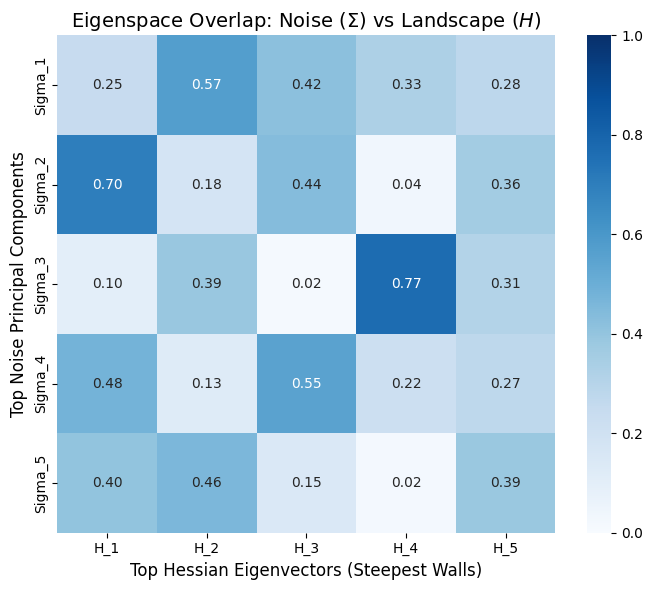

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader

# --- Settings ---
K = 5  # Number of top dimensions to compare
B = 64 # Mini-batch size for the noise
num_noise_samples = 500

print(f"--- Phase 3: Microscopic Alignment (Sigma vs Hessian) ---")
print("1. Sampling gradient noise...")

trained_model.eval()
criterion = torch.nn.CrossEntropyLoss()
device = next(trained_model.parameters()).device

# Function to get flattened gradient
def get_flat_gradient(X_batch, y_batch):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    trained_model.zero_grad()
    loss = criterion(trained_model(X_batch), y_batch)
    loss.backward()
    grads = [p.grad.contiguous().view(-1) for p in trained_model.parameters() if p.grad is not None]
    return torch.cat(grads)

# Get True Gradient (Full Batch)
# Note: For N=10000 you can load it in one batch, or accumulate it. 
# We'll assume full_dataloader can yield the whole dataset for the true gradient.
X_full, y_full = next(iter(full_dataloader))
true_grad = get_flat_gradient(X_full, y_full).detach().cpu().numpy()

# Sample mini-batch noise
mini_loader = DataLoader(dataset, batch_size=B, shuffle=True)
loader_iter = iter(mini_loader)

noise_matrix = []
for _ in range(num_noise_samples):
    try:
        X, y = next(loader_iter)
    except StopIteration:
        loader_iter = iter(mini_loader)
        X, y = next(loader_iter)
    
    if len(X) != B: continue
    
    mini_grad = get_flat_gradient(X, y).detach().cpu().numpy()
    noise_vector = mini_grad - true_grad
    noise_matrix.append(noise_vector)

noise_matrix = np.array(noise_matrix) # Shape: (500, M)

print("2. Computing Top Principal Components of the Noise (Sigma)...")
# SVD extracts the eigenvectors of the covariance matrix
# Vh contains the principal components sorted by explained variance
U, S, Vh = np.linalg.svd(noise_matrix, full_matrices=False)
noise_eigenvectors = Vh[:K] # Top K directions of the noise

print("3. Computing Top Eigenvectors of the Hessian (H)...")
# We use Hessian-Vector Products to avoid memory explosion

def compute_hvp(v_np):
    """Calculates H * v exactly without forming H."""
    v_tensor = torch.tensor(v_np, dtype=torch.float32).to(device)
    hvp_accum = torch.zeros_like(v_tensor)
    
    # We accumulate over batches to save GPU/CPU memory
    for X_b, y_b in DataLoader(dataset, batch_size=500):
        X_b, y_b = X_b.to(device), y_b.to(device)
        trained_model.zero_grad()
        loss = criterion(trained_model(X_b), y_b)
        
        # 1st derivative
        grads = torch.autograd.grad(loss, trained_model.parameters(), create_graph=True)
        flat_grad = torch.cat([g.contiguous().view(-1) for g in grads])
        
        # Dot product with vector v
        grad_v = torch.dot(flat_grad, v_tensor)
        
        # 2nd derivative (Hessian-vector product)
        hvp_grads = torch.autograd.grad(grad_v, trained_model.parameters())
        flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp_grads])
        
        hvp_accum += flat_hvp * len(X_b)
        
    return (hvp_accum / len(dataset)).detach().cpu().numpy()

# Define the matrix-free Linear Operator for SciPy
M = sum(p.numel() for p in trained_model.parameters())
H_op = LinearOperator((M, M), matvec=compute_hvp)

# scipy.sparse.linalg.eigsh finds the top K eigenvalues/eigenvectors using Lanczos iteration
evals, evecs = eigsh(H_op, k=K, which='LA')
# evecs are returned in ascending order, so we reverse them
hessian_eigenvectors = evecs[:, ::-1].T # Shape: (K, M)

print("4. Calculating Subspace Overlap...")
# We take the absolute dot product (cosine similarity) between the two sets of vectors
overlap_matrix = np.abs(np.dot(noise_eigenvectors, hessian_eigenvectors.T))

print("Plotting the Alignment Heatmap...")
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(overlap_matrix, annot=True, cmap='Blues', fmt=".2f", 
            xticklabels=[f"H_{i+1}" for i in range(K)], 
            yticklabels=[f"Sigma_{i+1}" for i in range(K)], 
            vmin=0, vmax=1, ax=ax)

ax.set_title("Eigenspace Overlap: Noise ($\Sigma$) vs Landscape ($H$)", fontsize=14)
ax.set_xlabel("Top Hessian Eigenvectors (Steepest Walls)", fontsize=12)
ax.set_ylabel("Top Noise Principal Components", fontsize=12)

plt.tight_layout()
plt.savefig("Hessian_Noise_Alignment.png", dpi=300)
plt.show()


--- Step 4: Verification of the Quadratic Local Approximation ---
Scanning the loss landscape along the steepest Hessian eigenvector...
Plotting the Quadratic Approximation...


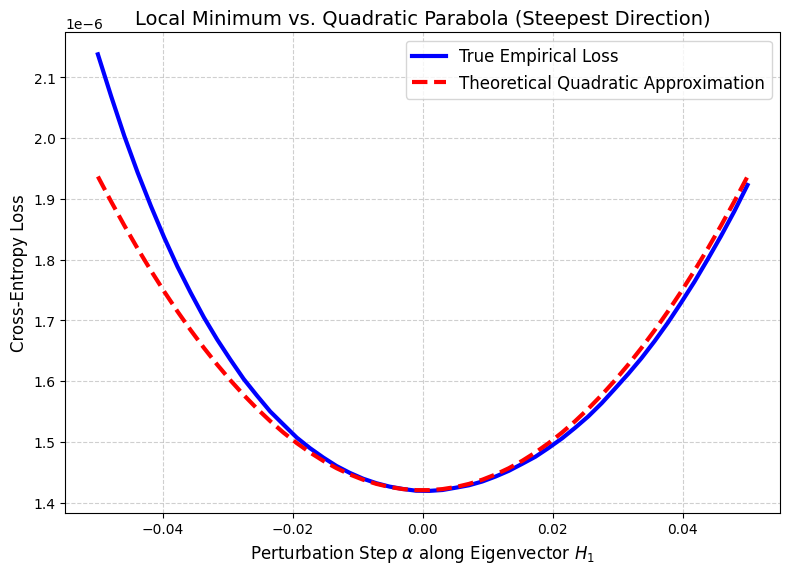

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy

print("--- Step 4: Verification of the Quadratic Local Approximation ---")

trained_model.eval()
device = next(trained_model.parameters()).device
X_all = dataset.tensors[0].to(device)
y_all = dataset.tensors[1].to(device)

# 1. Get the baseline loss at the minimum theta*
with torch.no_grad():
    loss_baseline = criterion(trained_model(X_all), y_all).item()

# 2. Extract the steepest direction (H_1) and its eigenvalue
# evals and hessian_eigenvectors come directly from the scipy.sparse.linalg.eigsh output in Step 3
lambda_1 = evals[-1]  # The largest eigenvalue
v_1 = hessian_eigenvectors[0] # The corresponding eigenvector

# Get the original weights as a single flattened vector
original_weights = torch.cat([p.data.contiguous().view(-1) for p in trained_model.parameters()])

# 3. Define the perturbation range (alpha)
alphas = np.linspace(-0.05, 0.05, 50)
true_losses = []
quadratic_losses = []

print("Scanning the loss landscape along the steepest Hessian eigenvector...")

for alpha in alphas:
    # --- Calculate Theoretical Quadratic Loss ---
    # L(theta) = L(theta*) + 0.5 * lambda * alpha^2
    quad_loss = loss_baseline + 0.5 * lambda_1 * (alpha ** 2)
    quadratic_losses.append(quad_loss)
    
    # --- Calculate True Empirical Loss ---
    # Perturb the weights: theta = theta* + alpha * v_1
    perturbed_weights = original_weights + alpha * torch.tensor(v_1, dtype=torch.float32).to(device)
    
    # Temporarily load perturbed weights into the model
    idx = 0
    for p in trained_model.parameters():
        numel = p.numel()
        p.data.copy_(perturbed_weights[idx:idx+numel].view_as(p.data))
        idx += numel
        
    # Measure actual loss
    with torch.no_grad():
        actual_loss = criterion(trained_model(X_all), y_all).item()
    true_losses.append(actual_loss)

# Restore the original weights to the model so we don't ruin theta* !
idx = 0
for p in trained_model.parameters():
    numel = p.numel()
    p.data.copy_(original_weights[idx:idx+numel].view_as(p.data))
    idx += numel

print("Plotting the Quadratic Approximation...")

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(alphas, true_losses, 'b-', linewidth=3, label="True Empirical Loss")
ax.plot(alphas, quadratic_losses, 'r--', linewidth=3, label="Theoretical Quadratic Approximation")

ax.set_title("Local Minimum vs. Quadratic Parabola (Steepest Direction)", fontsize=14)
ax.set_xlabel(r"Perturbation Step $\alpha$ along Eigenvector $H_1$", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig("Quadratic_Approximation.png", dpi=300)
plt.show()


--- Statistical Goodness-of-Fit Test for Quadratic Approximation ---

Fitted Quadratic:  0.000240·α²  +  -0.000001·α  +  0.000001
Theoretical:       0.000207·α²  +  0.000000·α  +  0.000001

R²                        = 0.99104238  (1.0 = perfect quadratic fit)
Relative error on λ₁/2    = 16.0206%


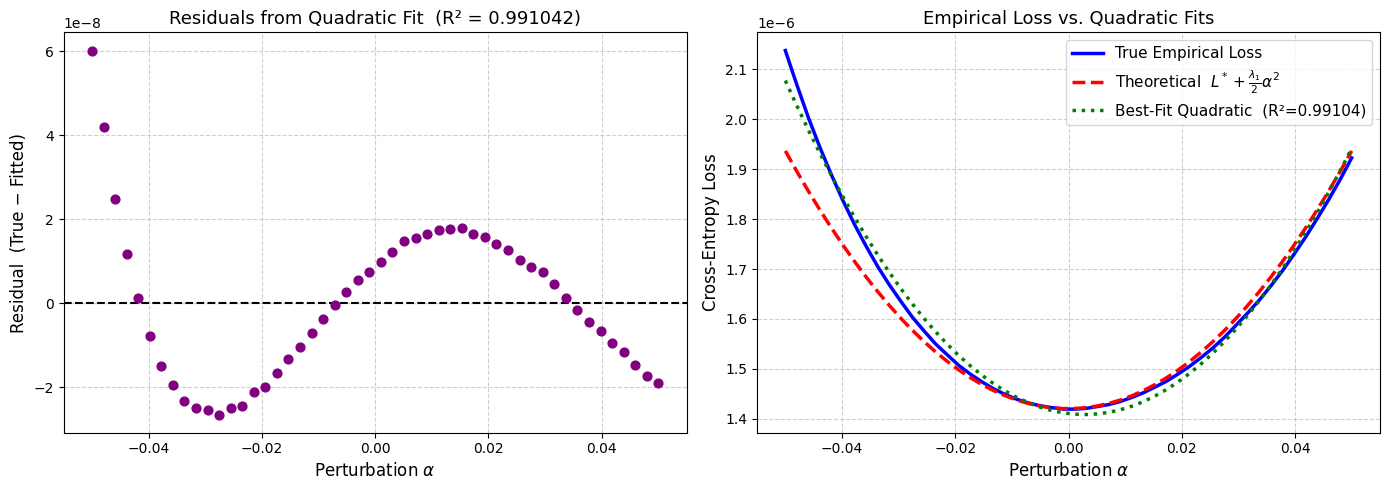

In [17]:
print("--- Statistical Goodness-of-Fit Test for Quadratic Approximation ---")

alphas_arr = np.array(alphas)
true_losses_arr = np.array(true_losses)

# 1. Fit a degree-2 polynomial to the empirical data
coeffs = np.polyfit(alphas_arr, true_losses_arr, deg=2)
a_fit, b_fit, c_fit = coeffs
quad_fitted = np.polyval(coeffs, alphas_arr)

# 2. R² (coefficient of determination): how much variance is explained by a quadratic
ss_res = np.sum((true_losses_arr - quad_fitted) ** 2)
ss_tot = np.sum((true_losses_arr - np.mean(true_losses_arr)) ** 2)
r_squared = 1.0 - ss_res / ss_tot

# 3. Compare fitted curvature against theoretical prediction (lambda_1 / 2)
a_theory = lambda_1 / 2.0
b_theory = 0.0
c_theory = loss_baseline
rel_err = abs(a_fit - a_theory) / abs(a_theory) * 100

print(f"\nFitted Quadratic:  {a_fit:.6f}·α²  +  {b_fit:.6f}·α  +  {c_fit:.6f}")
print(f"Theoretical:       {a_theory:.6f}·α²  +  {b_theory:.6f}·α  +  {c_theory:.6f}")
print(f"\nR²                        = {r_squared:.8f}  (1.0 = perfect quadratic fit)")
print(f"Relative error on λ₁/2    = {rel_err:.4f}%")

# 4. Residuals from the best-fit quadratic
residuals = true_losses_arr - quad_fitted

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: residual plot — should be flat/structureless if loss is truly quadratic
axes[0].scatter(alphas_arr, residuals, color='purple', s=40, zorder=5)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title(f"Residuals from Quadratic Fit  (R² = {r_squared:.6f})", fontsize=13)
axes[0].set_xlabel(r"Perturbation $\alpha$", fontsize=12)
axes[0].set_ylabel("Residual  (True − Fitted)", fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Right: three-way comparison — empirical, theoretical (Hessian), best-fit polynomial
axes[1].plot(alphas_arr, true_losses_arr, 'b-', linewidth=2.5, label="True Empirical Loss")
axes[1].plot(alphas_arr, np.array(quadratic_losses), 'r--', linewidth=2.5,
             label=r"Theoretical  $L^* + \frac{\lambda_1}{2}\alpha^2$")
axes[1].plot(alphas_arr, quad_fitted, 'g:', linewidth=2.5,
             label=f"Best-Fit Quadratic  (R²={r_squared:.5f})")
axes[1].set_title("Empirical Loss vs. Quadratic Fits", fontsize=13)
axes[1].set_xlabel(r"Perturbation $\alpha$", fontsize=12)
axes[1].set_ylabel("Cross-Entropy Loss", fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig("Quadratic_Fit_Test.png", dpi=300)
plt.show()


--- Step 4.2: Generating the 2D Loss Landscape Contour Plot ---
Scanning a 2D plane through the landscape...
Anchor point: theta*. Directions: Steepest Hessian vs Random Flat.
Processed 50/625 points...
Processed 100/625 points...
Processed 150/625 points...
Processed 200/625 points...
Processed 250/625 points...
Processed 300/625 points...
Processed 350/625 points...
Processed 400/625 points...
Processed 450/625 points...
Processed 500/625 points...
Processed 550/625 points...
Processed 600/625 points...
Plotting the 2D Contour Map...


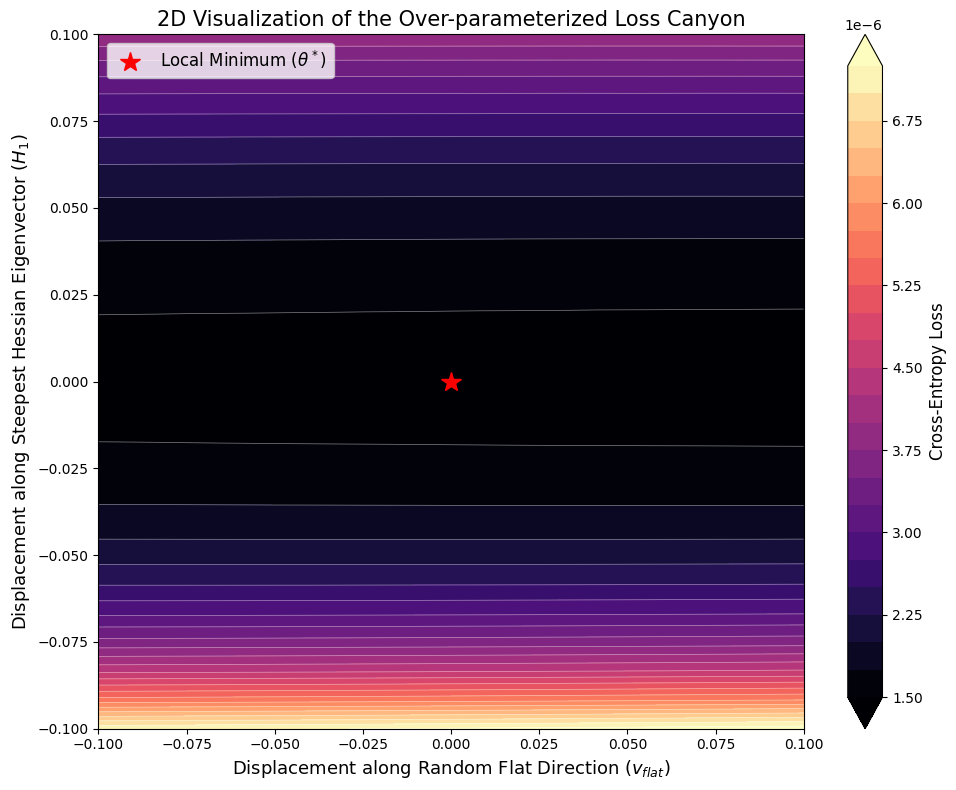

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

print("--- Step 4.2: Generating the 2D Loss Landscape Contour Plot ---")

# 1. Environment Setup
trained_model.eval()
criterion = torch.nn.CrossEntropyLoss()
device = next(trained_model.parameters()).device

# Get original weights and H_1 (v_1) from Step 3/4.1
original_weights = torch.cat([p.data.contiguous().view(-1) for p in trained_model.parameters()])
v_1 = torch.tensor(hessian_eigenvectors[0], dtype=torch.float32).to(device)  # H1: Steepest direction

# 2. Generate and Orthogonalize a Flat Direction
# We take a random Gaussian vector (guaranteed to be flat in over-parameterized nets)
v_rand = torch.randn_like(v_1)

# Project v_rand away from v_1 to make them strictly orthogonal
# Gram-Schmidt orthogonalization: v_2 = v_rand - proj_{v_1}(v_rand)
proj = torch.dot(v_rand, v_1) / torch.dot(v_1, v_1)
v_2_ortho = v_rand - proj * v_1

# Normalize both vectors so step size is Euclidean
v_steep = v_1 / torch.norm(v_1)
v_flat = v_2_ortho / torch.norm(v_2_ortho)

# 3. Setup the 2D Grid
grid_resolution = 25  # (Total of 25x25 = 625 forward passes)
alphas = np.linspace(-0.1, 0.1, grid_resolution)  # X-axis range (along H_1)
betas = np.linspace(-0.1, 0.1, grid_resolution)   # Y-axis range (along random flat dir)

loss_surface = np.zeros((grid_resolution, grid_resolution))

# Create optimized DataLoader for fast full-batch evaluation
dataloader_full = DataLoader(dataset, batch_size=1024, shuffle=False)

print(f"Scanning a 2D plane through the landscape...")
print(f"Anchor point: theta*. Directions: Steepest Hessian vs Random Flat.")

# Helper function to compute true loss efficiently
def compute_dataset_loss():
    total_loss = 0.0
    with torch.no_grad():
        for X_b, y_b in dataloader_full:
            X_b, y_b = X_b.to(device), y_b.to(device)
            loss = criterion(trained_model(X_b), y_b)
            total_loss += loss.item() * len(X_b)
    return total_loss / len(dataset)

# Nested loop to calculate the grid
counter = 0
total_cells = grid_resolution * grid_resolution
for i, alpha in enumerate(alphas):
    for j, beta in enumerate(betas):

        # --- Perturb the weights: theta = theta* + alpha*H1 + beta*random_flat ---
        perturbed_weights = original_weights + alpha * v_steep + beta * v_flat

        # Load perturbed weights into the model
        idx = 0
        for p in trained_model.parameters():
            numel = p.numel()
            p.data.copy_(perturbed_weights[idx:idx+numel].view_as(p.data))
            idx += numel

        # --- Compute actual loss ---
        loss_surface[i, j] = compute_dataset_loss()

        counter += 1
        if counter % 50 == 0:
            print(f"Processed {counter}/{total_cells} points...")

# --- 4. Restore the original weights to the model! ---
idx = 0
for p in trained_model.parameters():
    numel = p.numel()
    p.data.copy_(original_weights[idx:idx+numel].view_as(p.data))
    idx += numel

print("Plotting the 2D Contour Map...")

# Setup meshgrid for plotting
X_grid, Y_grid = np.meshgrid(betas, alphas)

fig, ax = plt.subplots(figsize=(10, 8))

# Contour Plot with filled colors
contour_f = ax.contourf(X_grid, Y_grid, loss_surface, levels=25, cmap='magma', extend='both')
# Overplot white contour lines for better definition
ax.contour(X_grid, Y_grid, loss_surface, levels=25, colors='white', linewidths=0.5, alpha=0.5)

# Plot the anchor point (theta*)
ax.plot(0, 0, 'r*', markersize=15, label=r'Local Minimum ($\theta^*$)')

ax.set_title(r"2D Visualization of the Over-parameterized Loss Canyon", fontsize=15)
ax.set_xlabel(r"Displacement along Random Flat Direction ($v_{flat}$)", fontsize=13)
ax.set_ylabel(r"Displacement along Steepest Hessian Eigenvector ($H_1$)", fontsize=13)

cbar = fig.colorbar(contour_f)
cbar.set_label("Cross-Entropy Loss", fontsize=12)
ax.legend(fontsize=12, loc='upper left')

plt.tight_layout()
plt.savefig("Loss_Landscape_2D_Canyon.png", dpi=300)
plt.show()
